In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from tqdm.auto import tqdm
from torch.utils.data import Subset
from evaluation import psnr, ssim 

## Model Architecture
Spa-Former for image inpainting.
- Generator: encoder-decoder with skip fusion.
- Gated Transformer blocks which use channel attention are used in the Generator
- Discriminator: PatchGAN-style conv network.


In [2]:
# supporting class for layer normalization
class ChannelLayerNorm(nn.Module):
    def __init__(self, dim):
        super().__init__()
        # GroupNorm(1, dim) is equivalent to LayerNorm over the channel dimension
        self.gn = nn.GroupNorm(1, dim)

    def forward(self, x):
        return self.gn(x)

### Spa-Attention Module
Sparse channel attention block used inside transformer layers.
- Builds attention with $q^\top k$ per head.
- Uses ReLU to keep sparse positive responses.
- Applies a spatial gate before projection.


In [3]:
class SpaAttention(nn.Module):
    def __init__(self, dim, num_heads=4, bias=False):
        super().__init__()
        assert dim % num_heads == 0, f"dim ({dim}) must be divisible by num_heads ({num_heads})"

        self.num_heads = num_heads
        self.temperature = nn.Parameter(torch.ones(num_heads, 1, 1))

        self.norm1 = ChannelLayerNorm(dim)
        self.gate = nn.Sequential(
            nn.Conv2d(dim, dim, kernel_size=1, bias=True),
            nn.GELU()
        )

        self.qkv = nn.Conv2d(dim, dim * 3, kernel_size=1, bias=bias)
        self.qkv_dwconv = nn.Conv2d(dim * 3, dim * 3, kernel_size=3, stride=1, padding=1, groups=dim * 3, bias=bias)
        self.project_out = nn.Conv2d(dim, dim, kernel_size=1, bias=bias)

    def forward(self, x, mask=None):
        b, c, h, w = x.shape
        x_n = self.norm1(x)
        
        # 1. Update the spatial gate to be mask-aware
        g = self.gate(x_n)
        if mask is not None:
            # Resize mask to current feature resolution (e.g., if in a bottleneck)
            mask_resized = F.interpolate(mask, size=(h, w), mode='nearest')
            g = g * mask_resized # Modulate the gate with the mask

        # 2. Standard Transposed Attention logic
        qkv = self.qkv_dwconv(self.qkv(x_n))
        q, k, v = qkv.chunk(3, dim=1)

        c_per_head = c // self.num_heads
        n = h * w

        q = q.view(b, self.num_heads, c_per_head, n).permute(0, 1, 3, 2)
        k = k.view(b, self.num_heads, c_per_head, n).permute(0, 1, 3, 2)
        v = v.view(b, self.num_heads, c_per_head, n).permute(0, 1, 3, 2)

        q = F.normalize(q, dim=2)
        k = F.normalize(k, dim=2)

        attn = (q.transpose(-2, -1) @ k) * self.temperature 
        attn = F.relu(attn)

        out = v @ attn
        out = out.permute(0, 1, 3, 2).contiguous().view(b, c, h, w)

        # 3. Apply the mask-modulated gate
        out = out * g
        out = self.project_out(out)
        return out


class FeedForward(nn.Module):
    def __init__(self, dim, expansion_factor=2.66):
        super().__init__()
        hidden = int(dim * expansion_factor)

        self.norm = ChannelLayerNorm(dim)
        self.conv = nn.Sequential(
            nn.Conv2d(dim, hidden * 2, kernel_size=1, bias=False),
            nn.Conv2d(hidden * 2, hidden * 2, kernel_size=3, stride=1, padding=1, groups=hidden * 2, bias=False),
        )
        self.linear = nn.Conv2d(hidden, dim, kernel_size=1, bias=False)

    def forward(self, x):
        x_n = self.norm(x)
        x1, x2 = self.conv(x_n).chunk(2, dim=1)
        out = F.gelu(x1) * x2
        out = self.linear(out)
        return out



### Gated Transformer Block
Combines attention and FFN with residual connections.
- $x \leftarrow x + \mathrm{Attention}(x)$
- $x \leftarrow x + \mathrm{FFN}(x)$
- Keeps block stable and easy to stack.


In [4]:
class TransformerBlock(nn.Module):
    def __init__(self, in_ch, head, expansion_factor=2.66):
        super().__init__()
        self.attn = SpaAttention(dim = in_ch, num_heads = head)
        self.ffn = FeedForward(dim = in_ch, expansion_factor=expansion_factor)

    def forward(self, x, mask=None):
        # Pass mask to attention
        x = x + self.attn(x, mask=mask)
        x = x + self.ffn(x)
        return x


class Downsample(nn.Module):
    def __init__(self, num_ch):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(num_ch, num_ch * 2, kernel_size=3, stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(num_ch * 2, track_running_stats=False),
            nn.GELU(),
        )

    def forward(self, x):
        return self.body(x)



### Encoder
Hierarchical feature extractor with 4 stages.
- Input is `[image, mask]` as 4 channels.
- Downsampling doubles channels and halves resolution.
- Returns pyramid features for decoder skip links.


In [5]:
class Encoder(nn.Module):
    def __init__(self, ngf=48, num_blocks=(1, 2, 3, 4), num_heads=(1, 2, 4, 8), expansion_factor=2.66):
        super().__init__()

        self.start = nn.Sequential(
            nn.ReflectionPad2d(3),
            nn.Conv2d(4, ngf, kernel_size=7, padding=0),
            nn.InstanceNorm2d(ngf),
            nn.GELU(),
        )

        self.trane256 = nn.Sequential(*[
            TransformerBlock(in_ch=ngf, head=num_heads[0], expansion_factor=expansion_factor)
            for _ in range(num_blocks[0])
        ])

        self.down128 = Downsample(ngf)
        self.trane128 = nn.Sequential(*[
            TransformerBlock(in_ch=ngf * 2, head=num_heads[1], expansion_factor=expansion_factor)
            for _ in range(num_blocks[1])
        ])

        self.down64 = Downsample(ngf * 2)
        self.trane64 = nn.Sequential(*[
            TransformerBlock(in_ch=ngf * 4, head=num_heads[2], expansion_factor=expansion_factor)
            for _ in range(num_blocks[2])
        ])

        self.down32 = Downsample(ngf * 4)
        self.trane32 = nn.Sequential(*[
            TransformerBlock(in_ch=ngf * 8, head=num_heads[3], expansion_factor=expansion_factor)
            for _ in range(num_blocks[3])
        ])

    def forward(self, x, mask=None, return_pyramid=False):
        if mask is None:
            mask = torch.ones(x.size(0), 1, x.size(2), x.size(3), dtype=x.dtype, device=x.device)

        feat = torch.cat([x, mask], dim=1)

        f256 = self.trane256(self.start(feat))
        f128 = self.trane128(self.down128(f256))
        f64 = self.trane64(self.down64(f128))
        f32 = self.trane32(self.down32(f64))

        if return_pyramid:
            return f256, f128, f64, f32
        return f32



### Upsampling and Decoder
Reconstructs image features back to full resolution.
- Nearest-neighbor upsample + conv refinement.
- Fuses skip features from encoder at each stage.
- Final $\tanh$ produces RGB output in $[-1, 1]$.


In [6]:
class Upsample(nn.Module):
    def __init__(self, num_ch):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(num_ch, num_ch // 2, kernel_size=3, stride=1, padding=1, bias=False),
            nn.InstanceNorm2d(num_ch // 2, track_running_stats=False),
            nn.GELU(),
        )

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        return self.body(x)


class Decoder(nn.Module):
    def __init__(self, ngf=48, num_blocks=(1, 2, 3, 4), num_heads=(1, 2, 4, 8), expansion_factor=2.66):
        super().__init__()

        self.up64 = Upsample(ngf * 8)
        self.fuse64 = nn.Conv2d(ngf * 8, ngf * 4, kernel_size=1, stride=1, bias=False)
        self.trand64 = nn.Sequential(*[
            TransformerBlock(in_ch=ngf * 4, head=num_heads[2], expansion_factor=expansion_factor)
            for _ in range(num_blocks[2])
        ])

        self.up128 = Upsample(ngf * 4)
        self.fuse128 = nn.Conv2d(ngf * 4, ngf * 2, kernel_size=1, stride=1, bias=False)
        self.trand128 = nn.Sequential(*[
            TransformerBlock(in_ch=ngf * 2, head=num_heads[1], expansion_factor=expansion_factor)
            for _ in range(num_blocks[1])
        ])

        self.up256 = Upsample(ngf * 2)
        self.fuse256 = nn.Conv2d(ngf * 2, ngf, kernel_size=1, stride=1, bias=False)
        self.trand256 = nn.Sequential(*[
            TransformerBlock(in_ch=ngf, head=num_heads[0], expansion_factor=expansion_factor)
            for _ in range(num_blocks[0])
        ])

        self.out = nn.Sequential(
            nn.ReflectionPad2d(3),
            nn.Conv2d(ngf, 3, kernel_size=7, padding=0),
        )

    def forward(self, f256, f128, f64, f32):
        out64 = self.up64(f32)
        out64 = self.fuse64(torch.cat([f64, out64], dim=1))
        out64 = self.trand64(out64)

        out128 = self.up128(out64)
        out128 = self.fuse128(torch.cat([f128, out128], dim=1))
        out128 = self.trand128(out128)

        out256 = self.up256(out128)
        out256 = self.fuse256(torch.cat([f256, out256], dim=1))
        out256 = self.trand256(out256)

        out = torch.tanh(self.out(out256))
        return out


class Generator(nn.Module):
    def __init__(self, ngf=48, num_blocks=(1, 2, 3, 4), num_heads=(1, 2, 4, 8), expansion_factor=2.66, use_input_noise=True):
        super().__init__()
        self.use_input_noise = use_input_noise
        self.encoder = Encoder(ngf=ngf, num_blocks=num_blocks, num_heads=num_heads, expansion_factor=expansion_factor)
        self.decoder = Decoder(ngf=ngf, num_blocks=num_blocks, num_heads=num_heads, expansion_factor=expansion_factor)

    def forward(self, x, mask):
        if self.use_input_noise:
            x = x + torch.randn_like(x) * (1.0 / 128.0)
        f256, f128, f64, f32 = self.encoder(x, mask, return_pyramid=True)
        out = self.decoder(f256, f128, f64, f32)
        return out


def composite_with_known_regions(pred, corrupted, mask, known_is_one=True):
    # Ensure mask is broadcastable and matches device
    if known_is_one:
        # If 1 is known, use pred where mask is 0 (hole) and corrupted where mask is 1
        return pred * (1.0 - mask) + corrupted * mask
    else:
        # If 0 is known, use pred where mask is 1 (hole) and corrupted where mask is 0
        return pred * mask + corrupted * (1.0 - mask)



#### Spectral Norm Helper
Utility wrapper for optional spectral normalization.
- Applied to discriminator conv layers.
- Constrains the layer Lipschitz constant $K$, so $\|\nabla f(x)\| \le K$.
- Helps stabilize GAN training.
- Can be toggled on/off by flag.


In [7]:
def spectral_norm(module, mode=True):
    if mode:
        return nn.utils.spectral_norm(module)

    return module

### GAN Discriminator
Patch-based discriminator used during training.
- Outputs a patch map (not one scalar), with each patch having a realism score.
- Returns intermediate conv features too.
- Supports adversarial and feature-based losses.


In [8]:
class Discriminator(nn.Module):
    def __init__(self, in_channels, use_spectral_norm=True, init_weights=True):
        super(Discriminator, self).__init__()

        self.conv1 = self.features = nn.Sequential(
            spectral_norm(nn.Conv2d(in_channels=in_channels, out_channels=64, kernel_size=4, stride=2, padding=1, bias=not use_spectral_norm), use_spectral_norm),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.conv2 = nn.Sequential(
            spectral_norm(nn.Conv2d(in_channels=64, out_channels=128, kernel_size=4, stride=2, padding=1, bias=not use_spectral_norm), use_spectral_norm),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.conv3 = nn.Sequential(
            spectral_norm(nn.Conv2d(in_channels=128, out_channels=256, kernel_size=4, stride=2, padding=1, bias=not use_spectral_norm), use_spectral_norm),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.conv4 = nn.Sequential(
            spectral_norm(nn.Conv2d(in_channels=256, out_channels=512, kernel_size=4, stride=1, padding=1, bias=not use_spectral_norm), use_spectral_norm),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.conv5 = nn.Sequential(
            spectral_norm(nn.Conv2d(in_channels=512, out_channels=1, kernel_size=4, stride=1, padding=1, bias=not use_spectral_norm), use_spectral_norm),
        )

    def forward(self, x):
        conv1 = self.conv1(x)
        conv2 = self.conv2(conv1)
        conv3 = self.conv3(conv2)
        conv4 = self.conv4(conv3)
        conv5 = self.conv5(conv4)

        outputs = conv5

        return outputs, [conv1, conv2, conv3, conv4, conv5]

## Training
Functions for one-step update and full epoch loop.
- `train_step`: updates D then G.
- `train_model`: loops through dataloader and logs averages.
- Supports optional perceptual/style losses.

Loss equations used in the training setup:

$$
\mathcal{L}_r = \lVert I_{out} - I_{gt} \rVert_1
$$

$$
\mathcal{L}_a = \mathbb{E}_{I_{gt}}\left[\log D(I_{gt})\right] + \mathbb{E}_{I_{out}}\left[\log\left(1 - D(I_{out})\right)\right]
$$

$$
\mathcal{L}_p = \sum_i \left\lVert \phi_i(I_{out}) - \phi_i(I_{gt}) \right\rVert_1
$$

$$
\mathcal{L}_s = \sum_i \left\lVert \phi_i(I_{out})\,\phi_i^{\top}(I_{out}) - \phi_i(I_{gt})\,\phi_i^{\top}(I_{gt}) \right\rVert_1
$$



In [9]:
# Train helpers (simple GAN + optional perceptual/style)
bce = nn.BCEWithLogitsLoss()


def d_loss_fn(d_real, d_fake):
    real_loss = bce(d_real, torch.ones_like(d_real))
    fake_loss = bce(d_fake, torch.zeros_like(d_fake))
    return 0.5 * (real_loss + fake_loss)


def g_adv_loss_fn(d_fake):
    return bce(d_fake, torch.ones_like(d_fake))


def l1_loss_fn(fake_img, real_img):
    return F.l1_loss(fake_img, real_img)


def gram_matrix(x):
    b, c, h, w = x.shape
    f = x.view(b, c, h * w)
    g = torch.bmm(f, f.transpose(1, 2))
    return g / (c * h * w)


class SimpleVGGFeatureExtractor(nn.Module):
    def __init__(self, layers=(3, 8, 15, 22)):
        super().__init__()
        self.layers = set(layers)
        self.max_layer = max(layers)

        try:
            vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).features
            self.pretrained_ok = True
        except Exception:
            vgg = models.vgg16(weights=None).features
            self.pretrained_ok = False

        self.features = vgg.eval()
        for p in self.features.parameters():
            p.requires_grad = False

        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, x):
        x = (x + 1.0) * 0.5
        x = (x - self.mean) / self.std

        outs = []
        h = x
        for i, layer in enumerate(self.features):
            h = layer(h)
            if i in self.layers:
                outs.append(h)
            if i >= self.max_layer:
                break
        return outs


def perceptual_style_loss(fake_img, real_img, feat_net):
    if feat_net is None:
        z = torch.tensor(0.0, device=fake_img.device)
        return z, z

    fake_feats = feat_net(fake_img)
    real_feats = feat_net(real_img)

    p_loss = 0.0
    s_loss = 0.0
    for ff, rf in zip(fake_feats, real_feats):
        p_loss = p_loss + F.l1_loss(ff, rf)
        s_loss = s_loss + F.l1_loss(gram_matrix(ff), gram_matrix(rf))
    return p_loss, s_loss


def set_requires_grad(model, flag=True):
    for p in model.parameters():
        p.requires_grad = flag


def unpack_batch(batch, device):
    if isinstance(batch, dict):
        img_truth = batch['img'].to(device, non_blocking=True)
        mask = batch['mask'].to(device, non_blocking=True)
    else:
        img_truth, mask = batch
        img_truth = img_truth.to(device, non_blocking=True)
        mask = mask.to(device, non_blocking=True)

    # FIX: Always normalize from [0, 1] to [-1, 1] 
    # since ToTensor() already handles the [0, 1] scaling.
    img_truth = img_truth * 2.0 - 1.0
    
    return img_truth, mask

def train_step(G, D, batch, opt_G, opt_D, device,
               feat_net=None,
               lambda_adv=0.1, lambda_l1=1.0, lambda_per=0.1, lambda_sty=250.0):
    G.train()
    D.train()

    img_truth, mask = unpack_batch(batch, device)
    img_m = img_truth * mask

    # --- Single G Pass ---
    # Generate prediction once for both D and G updates
    pred_fake = G(img_m, mask)
    img_fake = composite_with_known_regions(pred_fake, img_m, mask, known_is_one=True)

    # 1) D update
    set_requires_grad(D, True)
    opt_D.zero_grad()

    d_real, _ = D(img_truth)
    # Use .detach() so gradients don't flow back to G during D's step
    d_fake, _ = D(img_fake.detach()) 
    loss_d = d_loss_fn(d_real, d_fake)
    loss_d.backward()
    opt_D.step()

    # 2) G update
    set_requires_grad(D, False)
    opt_G.zero_grad()

    # Reuse the same img_fake generated above
    d_fake_for_g, _ = D(img_fake) 

    loss_g_adv = g_adv_loss_fn(d_fake_for_g)
    loss_g_l1 = l1_loss_fn(img_fake, img_truth)
    if feat_net is not None and (lambda_per > 0 or lambda_sty > 0):
        loss_g_per, loss_g_sty = perceptual_style_loss(img_fake, img_truth, feat_net)
    else:
        z = torch.tensor(0.0, device=img_fake.device)
        loss_g_per, loss_g_sty = z, z

    loss_g = (
        lambda_adv * loss_g_adv
        + lambda_l1 * loss_g_l1
        + lambda_per * loss_g_per
        + lambda_sty * loss_g_sty
    )

    loss_g.backward()
    opt_G.step()

    return {
        'loss_d': float(loss_d.detach()),
        'loss_g': float(loss_g.detach()),
        'loss_g_adv': float(loss_g_adv.detach()),
        'loss_g_l1': float(loss_g_l1.detach()),
        'loss_g_per': float(loss_g_per.detach()),
        'loss_g_sty': float(loss_g_sty.detach()),
    }


def train_model(
    G,
    D,
    dataloader,
    epochs=1,
    lr=1e-4,
    device='cpu',
    use_perceptual_style=True,
    ckpt_path='/kaggle/working/checkpoints/spaformer_latest.pt',
    load_ckpt=False,
    save_ckpt=True,
    save_every=5,
):
    from pathlib import Path

    G.to(device)
    D.to(device)

    feat_net = None
    if use_perceptual_style:
        feat_net = SimpleVGGFeatureExtractor().to(device)
        feat_net.eval()
        # Freeze parameters 
        for param in feat_net.parameters():
            param.requires_grad = False

    opt_G = torch.optim.AdamW(G.parameters(), lr=lr, betas=(0.5, 0.9))
    opt_D = torch.optim.AdamW(D.parameters(), lr=lr, betas=(0.5, 0.9))

    history = []
    start_epoch = 0

    ckpt_file = Path(ckpt_path) if ckpt_path is not None else None
    if load_ckpt and ckpt_file is not None and ckpt_file.exists():
        ckpt = torch.load(str(ckpt_file), map_location=device, weights_only=False)
        G.load_state_dict(ckpt['G'])
        D.load_state_dict(ckpt['D'])
        if 'opt_G' in ckpt:
            opt_G.load_state_dict(ckpt['opt_G'])
        if 'opt_D' in ckpt:
            opt_D.load_state_dict(ckpt['opt_D'])
        history = ckpt.get('history', [])
        start_epoch = int(ckpt.get('epoch', -1)) + 1
        print(f"Loaded checkpoint: {ckpt_file} (resume at epoch {start_epoch + 1})")

    for epoch in range(start_epoch, start_epoch + epochs):
        running = {'loss_d': 0.0, 'loss_g': 0.0, 'loss_g_adv': 0.0, 'loss_g_l1': 0.0, 'loss_g_per': 0.0, 'loss_g_sty': 0.0}
        count = 0

        progress = tqdm(dataloader, desc=f"Epoch {epoch+1}/{start_epoch + epochs}", leave=False)
        for step, batch in enumerate(progress, start=1):
            metrics = train_step(G, D, batch, opt_G, opt_D, device, feat_net=feat_net)
            for k in running:
                running[k] += metrics[k]
            count += 1
            progress.set_postfix({'D': f"{metrics['loss_d']:.4f}", 'G': f"{metrics['loss_g']:.4f}", 'G_Perceptual': f"{metrics['loss_g_per']:.4f}",'G_style': f"{metrics['loss_g_sty']:.4f}"})

        for k in running:
            running[k] /= max(count, 1)

        history.append(running)
        print(f"Epoch {epoch+1} | D: {running['loss_d']:.4f} | G: {running['loss_g']:.4f} | L1: {running['loss_g_l1']:.4f}, G_per: {running['loss_g_per']:.4f}, G_style: {running['loss_g_sty']:.4f}")

        if save_ckpt and ckpt_file is not None and ((epoch + 1) % save_every == 0):
            ckpt_file.parent.mkdir(parents=True, exist_ok=True)
            torch.save({
                'epoch': epoch,
                'G': G.state_dict(),
                'D': D.state_dict(),
                'opt_G': opt_G.state_dict(),
                'opt_D': opt_D.state_dict(),
                'history': history,
            }, str(ckpt_file))
            print(f"Saved checkpoint: {ckpt_file}")

    return history


# Example usage (with your own DataLoader):
# G = Generator(use_input_noise=True)
# D = Discriminator(in_channels=3, use_sigmoid=True, use_spectral_norm=True)
# history = train_model(G, D, train_loader, epochs=10, lr=1e-4, device='cuda', use_perceptual_style=True)





In [10]:
# Simplified in-notebook task helpers (mask generation used by the dataloader)
import random
import numpy as np
import cv2
from random import randint
from PIL import Image
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms


def random_regular_mask(img):
    s = img.size()
    mask = torch.ones(1, s[1], s[2])
    n_mask = random.randint(1, 5)
    limx = s[1] - s[1] / (n_mask + 1)
    limy = s[2] - s[2] / (n_mask + 1)
    for _ in range(n_mask):
        x = random.randint(0, int(limx))
        y = random.randint(0, int(limy))
        range_x = x + random.randint(int(s[1] / (n_mask + 7)), int(s[1] - x))
        range_y = y + random.randint(int(s[2] / (n_mask + 7)), int(s[2] - y))
        mask[:, int(x):int(range_x), int(y):int(range_y)] = 0
    return mask


def center_mask(img):
    size = img.size()
    mask = torch.ones(1, size[1], size[2])
    x = int(size[1] / 4)
    y = int(size[2] / 4)
    range_x = int(size[1] * 3 / 4)
    range_y = int(size[2] * 3 / 4)
    mask[:, x:range_x, y:range_y] = 0
    return mask


def random_irregular_mask(img):
    to_tensor = transforms.Compose([transforms.ToTensor()])
    size = img.size()
    mask = torch.ones(1, size[1], size[2])
    canvas = np.zeros((size[1], size[2], 1), np.uint8)

    max_width = 20
    if size[1] < 64 or size[2] < 64:
        raise Exception('Width and Height of mask must be at least 64!')

    number = random.randint(16, 64)
    for _ in range(number):
        mode = random.random()
        if mode < 0.6:
            x1, x2 = randint(1, size[1]), randint(1, size[1])
            y1, y2 = randint(1, size[2]), randint(1, size[2])
            thickness = randint(4, max_width)
            cv2.line(canvas, (x1, y1), (x2, y2), (1, 1, 1), thickness)
        elif mode < 0.8:
            x1, y1 = randint(1, size[1]), randint(1, size[2])
            radius = randint(4, max_width)
            cv2.circle(canvas, (x1, y1), radius, (1, 1, 1), -1)
        else:
            x1, y1 = randint(1, size[1]), randint(1, size[2])
            s1, s2 = randint(1, size[1]), randint(1, size[2])
            a1, a2, a3 = randint(3, 180), randint(3, 180), randint(3, 180)
            thickness = randint(4, max_width)
            cv2.ellipse(canvas, (x1, y1), (s1, s2), a1, a2, a3, (1, 1, 1), thickness)

    canvas = canvas.reshape(size[2], size[1])
    pil_mask = Image.fromarray(canvas * 255)
    img_mask = to_tensor(pil_mask)
    mask[0, :, :] = img_mask < 1
    return mask


def random_freefrom_mask(img, mv=5, ma=4.0, ml=40, mbw=10):
    to_tensor = transforms.Compose([transforms.ToTensor()])
    size = img.size()
    mask = torch.ones(1, size[1], size[2])
    canvas = np.zeros((size[1], size[2], 1), np.uint8)
    num_v = 12 + np.random.randint(mv)

    for i in range(num_v):
        start_x = np.random.randint(size[1])
        start_y = np.random.randint(size[2])
        for _ in range(1 + np.random.randint(5)):
            angle = 0.01 + np.random.randint(ma)
            if i % 2 == 0:
                angle = 2 * 3.1415926 - angle
            length = 10 + np.random.randint(ml)
            brush_w = 10 + np.random.randint(mbw)
            end_x = (start_x + length * np.sin(angle)).astype(np.int32)
            end_y = (start_y + length * np.cos(angle)).astype(np.int32)

            cv2.line(canvas, (start_y, start_x), (end_y, end_x), 1.0, brush_w)
            start_x, start_y = end_x, end_y

    canvas = canvas.reshape(size[2], size[1])
    pil_mask = Image.fromarray(canvas * 255)
    img_mask = to_tensor(pil_mask)
    mask[0, :, :] = img_mask < 1
    return mask


def four_mask(img):
    size = img.size()
    h, w = size[1], size[2]
    mask = torch.ones(1, h, w)
    hq = h // 2
    wq = w // 2
    q = random.randint(0, 3)
    if q == 0:
        mask[:, :hq, :wq] = 0
    elif q == 1:
        mask[:, :hq, wq:] = 0
    elif q == 2:
        mask[:, hq:, :wq] = 0
    else:
        mask[:, hq:, wq:] = 0
    return mask


def scale_img(img, size):
    return F.interpolate(img, size=size, mode='bilinear', align_corners=True)


def scale_pyramid(img, num_scales):
    scaled_imgs = [img]
    h, w = img.size(2), img.size(3)
    for i in range(1, num_scales):
        ratio = 2 ** i
        scaled_imgs.append(scale_img(img, size=[h // ratio, w // ratio]))
    scaled_imgs.reverse()
    return scaled_imgs



In [11]:
# Simplified in-notebook dataloader (equivalent behavior for mask types used here)
import os
import random
from PIL import Image, ImageFile
import torch
import torch.utils.data as data
import torchvision.transforms as transforms

ImageFile.LOAD_TRUNCATED_IMAGES = True


def _build_transform(opt):
    transform_list = []
    load_size = [opt.loadSize[0], opt.loadSize[1]]
    fine_size = [opt.fineSize[0], opt.fineSize[1]]

    if opt.isTrain:
        if opt.resize_or_crop == 'resize_and_crop':
            transform_list.append(transforms.Resize(load_size))
            transform_list.append(transforms.RandomCrop(fine_size))
        elif opt.resize_or_crop == 'crop':
            transform_list.append(transforms.RandomCrop(fine_size))

        if not getattr(opt, 'no_augment', False):
            transform_list.append(transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2))
        if not getattr(opt, 'no_flip', False):
            transform_list.append(transforms.RandomHorizontalFlip())
        if not getattr(opt, 'no_rotation', False):
            transform_list.append(transforms.RandomRotation(3))
    else:
        transform_list.append(transforms.Resize(fine_size))

    transform_list.append(transforms.ToTensor())
    return transforms.Compose(transform_list)


class SimpleInpaintDataset(data.Dataset):
    def __init__(self, opt):
        self.opt = opt
        self.img_paths = sorted(
            os.path.join(opt.img_file, f)
            for f in os.listdir(opt.img_file)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        )
        self.transform = _build_transform(opt)

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, index):
        img_path = self.img_paths[index]
        with Image.open(img_path).convert('RGB') as pil_img:
            img = self.transform(pil_img)

        mask_type = random.choice(self.opt.mask_type)
        if mask_type == 0:
            mask = center_mask(img)
        elif mask_type == 1:
            mask = random_regular_mask(img)
        elif mask_type == 2:
            mask = random_irregular_mask(img)
        elif mask_type == 4:
            mask = random_freefrom_mask(img)
        elif mask_type == 9:
            mask = four_mask(img)
        else:
            raise ValueError(f'Unsupported mask_type in simplified loader: {mask_type}')

        return {'img': img, 'img_path': img_path, 'mask': mask}


def make_dataloader(opt):
    dataset = SimpleInpaintDataset(opt)
    num_workers = int(opt.nThreads)
    loader_kwargs = dict(
        batch_size=opt.batchSize,
        shuffle=not opt.no_shuffle,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
    )
    if num_workers > 0:
        loader_kwargs['persistent_workers'] = True
        loader_kwargs['prefetch_factor'] = 2

    return data.DataLoader(dataset, **loader_kwargs)



train_loader ready
img shape: (4, 3, 256, 256) dtype: torch.float32 min/max: 0.0 1.0
mask shape: (4, 1, 256, 256) dtype: torch.float32 min/max: 0.0 1.0
sample path: /kaggle/input/datasets/badasstechie/celebahq-resized-256x256/celeba_hq_256/08354.jpg


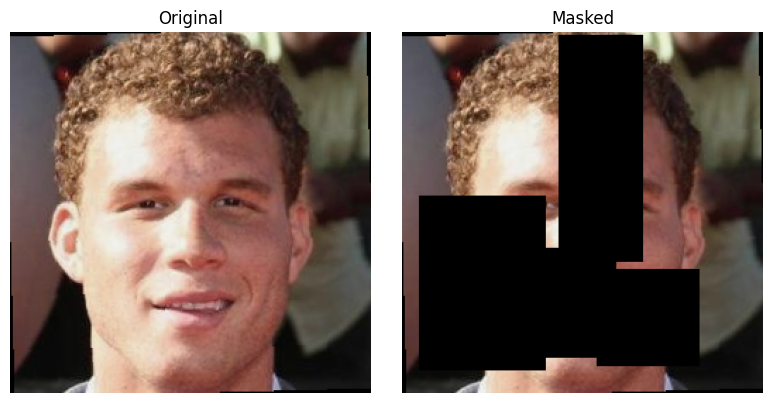

In [12]:
# Train loader sample using dataloader.py
from types import SimpleNamespace
import matplotlib.pyplot as plt

opt = SimpleNamespace(
    img_file='/kaggle/input/datasets/badasstechie/celebahq-resized-256x256/celeba_hq_256',
    mask_type=[0, 1, 2, 4],
    isTrain=True,
    batchSize=4,
    no_shuffle=False,
    nThreads=0,
    loadSize=[256, 256],
    fineSize=[256, 256],
    resize_or_crop='resize_and_crop',
    no_augment=False,
    no_flip=False,
    no_rotation=False,
)

train_loader = make_dataloader(opt)
batch = next(iter(train_loader))

img = batch['img']
mask = batch['mask']
img_path = batch['img_path']

print('train_loader ready')
print('img shape:', tuple(img.shape), 'dtype:', img.dtype, 'min/max:', float(img.min()), float(img.max()))
print('mask shape:', tuple(mask.shape), 'dtype:', mask.dtype, 'min/max:', float(mask.min()), float(mask.max()))
print('sample path:', img_path[0])

# plot original + masked sample
sample_img = img[0].detach().cpu()                 # [3, H, W]
sample_mask = mask[0].detach().cpu()               # [1, H, W] or [H, W]
if sample_mask.dim() == 3:
    sample_mask_2d = sample_mask[0]
else:
    sample_mask_2d = sample_mask

masked_img = sample_img * sample_mask_2d.unsqueeze(0)

orig_np = sample_img.permute(1, 2, 0).clamp(0, 1)
masked_np = masked_img.permute(1, 2, 0).clamp(0, 1)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(orig_np)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(masked_np)
plt.title('Masked')
plt.axis('off')

plt.tight_layout()
plt.show()


In [13]:
# Quick sanity training on 50 images
from types import SimpleNamespace
from torch.utils.data import Subset, DataLoader

opt = SimpleNamespace(
    img_file='/kaggle/input/datasets/badasstechie/celebahq-resized-256x256/celeba_hq_256',
    mask_type=[0, 1, 2, 4],
    isTrain=True,
    batchSize=4,
    no_shuffle=False,
    nThreads=0,
    loadSize=[256, 256],
    fineSize=[256, 256],
    resize_or_crop='resize_and_crop',
    no_augment=False,
    no_flip=False,
    no_rotation=False,
)

full_loader = make_dataloader(opt)
dataset = full_loader.dataset
n = 2000
subset_idx = torch.randperm(len(dataset))[:n].tolist()
subset_ds = Subset(dataset, subset_idx)
loader_kwargs = dict(
    batch_size=opt.batchSize,
    shuffle=True,
    num_workers=int(opt.nThreads),
    pin_memory=torch.cuda.is_available(),
)
if int(opt.nThreads) > 0:
    loader_kwargs['persistent_workers'] = True
    loader_kwargs['prefetch_factor'] = 2
train_loader = DataLoader(subset_ds, **loader_kwargs)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
G = Generator(use_input_noise=True)
D = Discriminator(in_channels=3, use_spectral_norm=True)

history = train_model(
    G, D, train_loader,
    epochs=40,
    lr=1e-4,
    device=device,
    use_perceptual_style=True,
    ckpt_path='checkpoints/spaformer_latest.pt',
    load_ckpt=False,
    save_ckpt=True,
    save_every=5,
)
history[-1]



Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 226MB/s] 


Epoch 1/40:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 1 | D: 0.6690 | G: 1.3126 | L1: 0.1133, G_per: 1.6250, G_style: 0.0039


Epoch 2/40:   0%|          | 0/500 [00:00<?, ?it/s]

...

Epoch 39/40:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 39 | D: 0.6700 | G: 0.5765 | L1: 0.0492, G_per: 1.1184, G_style: 0.0014


Epoch 40/40:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 40 | D: 0.6692 | G: 0.5852 | L1: 0.0504, G_per: 1.1427, G_style: 0.0014
Saved checkpoint: checkpoints/spaformer_latest.pt


{'loss_d': 0.6691581866741181,
 'loss_g': 0.5851938263773918,
 'loss_g_adv': 0.7351082209348678,
 'loss_g_l1': 0.05040670902282,
 'loss_g_per': 1.1426849786043167,
 'loss_g_sty': 0.0013880311765242367}

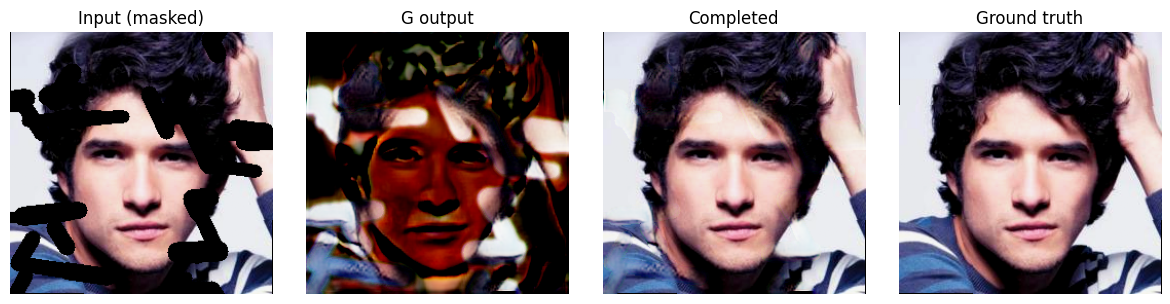

In [22]:
# Sample Generator I/O visualization (input -> G output -> completed image)
G.eval()

batch = next(iter(train_loader))
img_truth = batch['img'].to(device)   # [B,3,H,W], usually in [0,1]
mask = batch['mask'].to(device)       # [B,1,H,W], 1=known, 0=hole (as used in your code)

img_m = img_truth * mask  # input to Generator (masked image)

with torch.no_grad():
    pred = G(img_m, mask)  # raw Generator output
    completed = composite_with_known_regions(pred, img_m, mask, known_is_one=True)

# first sample
x_in = img_m[0].detach().cpu().permute(1, 2, 0).clamp(0, 1)
x_out = pred[0].detach().cpu().permute(1, 2, 0).clamp(0, 1)
x_comp = completed[0].detach().cpu().permute(1, 2, 0).clamp(0, 1)
x_gt = img_truth[0].detach().cpu().permute(1, 2, 0).clamp(0, 1)

plt.figure(figsize=(12, 3))
plt.subplot(1, 4, 1); plt.imshow(x_in);   plt.title("Input (masked)"); plt.axis("off")
plt.subplot(1, 4, 2); plt.imshow(x_out);  plt.title("G output");        plt.axis("off")
plt.subplot(1, 4, 3); plt.imshow(x_comp); plt.title("Completed");       plt.axis("off")
plt.subplot(1, 4, 4); plt.imshow(x_gt);   plt.title("Ground truth");    plt.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
def validate_model(G, original_opt, num_samples=500, device='cuda'):
    """
    Samples 500 images from the dataset, applies the same preprocessing,
    and calculates PSNR and SSIM.
    """
    G.eval()
    full_dataset = SimpleInpaintDataset(original_opt)
    
    all_indices = list(range(len(full_dataset)))
    subset_indices = random.sample(all_indices, min(num_samples, len(all_indices)))
    val_subset = Subset(full_dataset, subset_indices)
    
    val_loader = torch.utils.data.DataLoader(
        val_subset, 
        batch_size=original_opt.batchSize, 
        shuffle=False, 
        num_workers=original_opt.nThreads
    )

    total_psnr = 0.0
    total_ssim = 0.0
    count = 0

    print(f"Starting validation on {len(subset_indices)} samples...")
    
    with torch.no_grad():
        for batch in val_loader:
            img_truth, mask = unpack_batch(batch, device)
            img_m = img_truth * mask
            
            pred_fake = G(img_m, mask)
            img_fake = composite_with_known_regions(pred_fake, img_m, mask, known_is_one=True)
            
            img_fake_norm = (img_fake + 1.0) / 2.0
            img_truth_norm = (img_truth + 1.0) / 2.0
            
            batch_psnr = psnr(img_fake_norm, img_truth_norm)
            batch_ssim = ssim(img_fake_norm, img_truth_norm)
            
            total_psnr += batch_psnr.item()
            total_ssim += batch_ssim.item()
            count += 1

    avg_psnr = total_psnr / count
    avg_ssim = total_ssim / count
    
    print("-" * 30)
    print(f"Validation Results:")
    print(f"Average PSNR: {avg_psnr:.4f} dB")
    print(f"Average SSIM: {avg_ssim:.4f}")
    print("-" * 30)
    
    return avg_psnr, avg_ssim

avg_psnr, avg_ssim = validate_model(G, opt, num_samples=500, device=device)